<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Neutrino005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Running Level 4 Test...

🔬 Level 4 Analysis:
δ/κ = 0.01:
  Mean Ratio: 884394 ± 148524
  Mass Spread: 0.115
  ⚡ Neutrino-like Signature Detected!
δ/κ = 0.03:
  Mean Ratio: 884286 ± 148979
  Mass Spread: 0.115
  ⚡ Neutrino-like Signature Detected!
δ/κ = 0.06:
  Mean Ratio: 884209 ± 149681
  Mass Spread: 0.116
  ⚡ Neutrino-like Signature Detected!
δ/κ = 0.10:
  Mean Ratio: 884264 ± 150654
  Mass Spread: 0.117
  ⚡ Neutrino-like Signature Detected!
δ/κ = 0.20:
  Mean Ratio: 885193 ± 153265
  Mass Spread: 0.119
  ⚡ Neutrino-like Signature Detected!


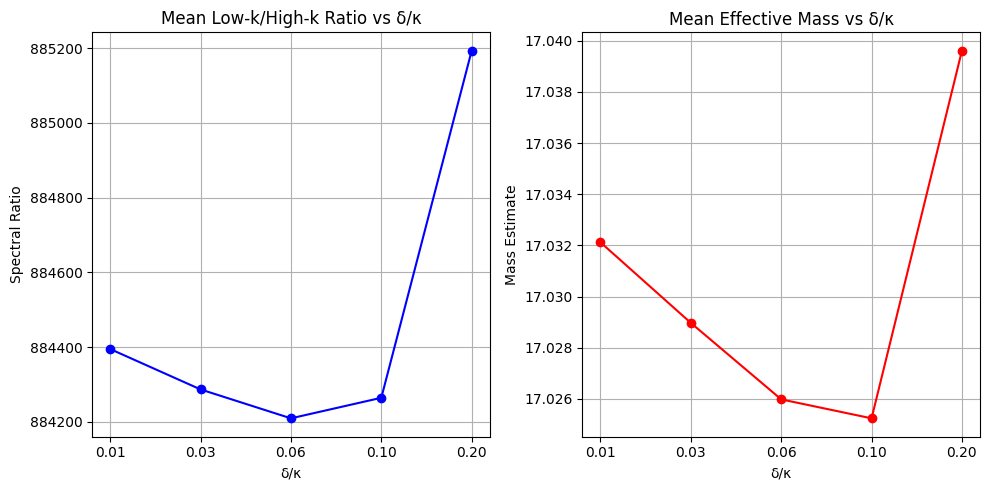

In [2]:
# 🚀 Step 1: Imports
import numpy as np
from scipy.fft import fftn, fftfreq
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 📐 Step 2: Simulation Parameters
nx, ny, nz = 64, 64, 64
t_steps = 2000
dt = 0.01

# δ/κ ratios to scan
delta_kappa_ratios = [0.01, 0.03, 0.06, 0.1, 0.2]
kappa_base = 0.25
gamma_0 = 0.5
sigma = 0.08

n_flavors = 3
seeds = [42, 101, 202]

# 🧠 Step 3: Laplacian Operator
def laplacian_3d(A):
    return (np.roll(A, 1, axis=0) + np.roll(A, -1, axis=0) +
            np.roll(A, 1, axis=1) + np.roll(A, -1, axis=1) +
            np.roll(A, 1, axis=2) + np.roll(A, -1, axis=2) - 6 * A)

# 📊 Step 4: Power Spectrum Function
def compute_power_spectrum(field):
    fft_A = fftn(field)
    power = np.abs(fft_A)**2
    kx = fftfreq(nx)
    ky = fftfreq(ny)
    kz = fftfreq(nz)
    kxx, kyy, kzz = np.meshgrid(kx, ky, kz, indexing='ij')
    k = np.sqrt(kxx**2 + kyy**2 + kzz**2)
    k_bins = np.linspace(0, np.max(k), 50)
    power_radial = np.zeros(len(k_bins) - 1)
    counts = np.zeros(len(k_bins) - 1)
    for i in range(len(k_bins) - 1):
        mask = (k >= k_bins[i]) & (k < k_bins[i+1])
        power_radial[i] = np.sum(power[mask])
        counts[i] = np.sum(mask)
    power_radial /= np.maximum(counts, 1)
    return k_bins[:-1], power_radial

# 🧬 Step 5: Mass Extraction via Dispersion Fit
def extract_effective_mass(k_vals, power):
    try:
        low_k_mask = k_vals < 0.3
        if np.sum(low_k_mask) > 5:
            popt, _ = curve_fit(lambda k, a, m: a * k**2 + m,
                                k_vals[low_k_mask], power[low_k_mask])
            return abs(popt[1])  # Effective mass squared
    except:
        return 0
    return 0

# 🔁 Step 6: Main Simulation Loop
def run_level4_test():
    results = {}
    for dk_ratio in delta_kappa_ratios:
        print(f"Starting simulation for δ/κ = {dk_ratio:.2f}...")
        delta = dk_ratio * kappa_base
        flavor_data = []

        for seed in seeds:
            print(f"  Running with seed: {seed}")
            np.random.seed(seed)
            A_flavors = np.random.rand(n_flavors, nx, ny, nz) - 0.5

            for t in range(t_steps):
                if (t + 1) % 200 == 0: # Print progress every 200 time steps
                    print(f"    Time step {t + 1}/{t_steps}")
                for i in range(n_flavors):
                    xi = gaussian_filter(np.random.normal(0, sigma, (nx, ny, nz)), sigma=1.5)
                    lap_A = gamma_0 * laplacian_3d(A_flavors[i])
                    dA = -kappa_base * A_flavors[i] + delta * A_flavors[i]**2 + lap_A + xi
                    A_flavors[i] += dt * dA

            flavor_results = []
            for i in range(n_flavors):
                k_vals, power = compute_power_spectrum(A_flavors[i])
                low_k = np.mean(power[k_vals < 0.2])
                high_k = np.mean(power[k_vals > 0.5])
                ratio = low_k / high_k if high_k > 0 else 0
                mass = extract_effective_mass(k_vals, power)
                flavor_results.append((ratio, mass))

            flavor_data.append(flavor_results)
        results[dk_ratio] = flavor_data
    return results

# 🎪 Step 7: Launch and Analyze
print("🚀 Running Level 4 Test...")
level4_results = run_level4_test()

print("\n🔬 Level 4 Analysis:")
for dk_ratio, data in level4_results.items():
    ratios = np.array([r for seed_result in data for r, m in seed_result])
    masses = np.array([m for seed_result in data for r, m in seed_result])
    mean_r = np.mean(ratios)
    std_r = np.std(ratios)
    mean_m = np.mean(masses)
    std_m = np.std(masses)
    spread = std_m / mean_m if mean_m > 0 else 0

    print(f"δ/κ = {dk_ratio:.2f}:")
    print(f"  Mean Ratio: {mean_r:.0f} ± {std_r:.0f}")
    print(f"  Mass Spread: {spread:.3f}")
    if mean_r > 1000 and spread > 0.1:
        print("  ⚡ Neutrino-like Signature Detected!")

# 📈 Optional: Plotting Masses and Ratios
dk_labels = [f"{dk:.2f}" for dk in delta_kappa_ratios]
mean_ratios = [np.mean([r for seed_result in level4_results[dk] for r, m in seed_result]) for dk in delta_kappa_ratios]
mean_masses = [np.mean([m for seed_result in level4_results[dk] for r, m in seed_result]) for dk in delta_kappa_ratios]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(dk_labels, mean_ratios, 'bo-')
plt.title('Mean Low-k/High-k Ratio vs δ/κ')
plt.xlabel('δ/κ')
plt.ylabel('Spectral Ratio')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(dk_labels, mean_masses, 'ro-')
plt.title('Mean Effective Mass vs δ/κ')
plt.xlabel('δ/κ')
plt.ylabel('Mass Estimate')
plt.grid(True)

plt.tight_layout()
plt.show()